Motor stall torque:   0.1500 Nm
Motor no-load speed:  1257.9 rad/s  (12012 RPM)
Gravity torque at horizontal: 1.4715 Nm
Motor can NOT overcome gravity at stall

Open-loop eigenvalues:   [ 5.71839138 -5.71839138]
Controllability rank:    2 / 2
LQR gain K:              [[-7.84499244 -2.31366045]]
Closed-loop eigenvalues: [ -3.17047862 -99.65887454]


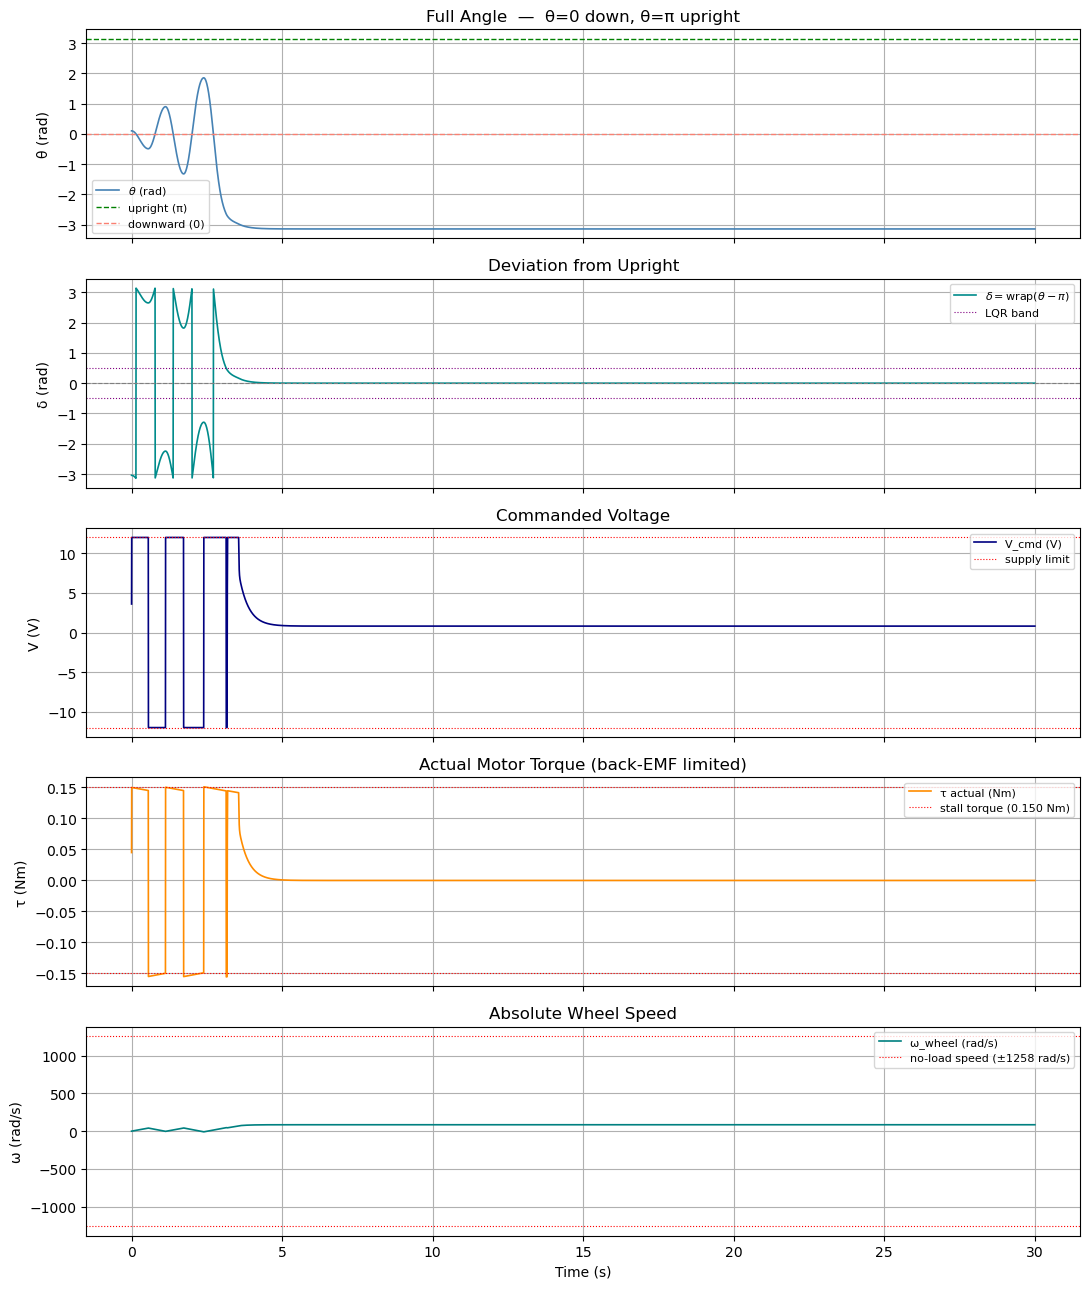


--- Final State ---
theta:        -3.1416 rad  (target π = 3.1416)
delta:        0.0000 rad  (target 0)
theta_dot:    -0.0000 rad/s
omega_wheel:  84.97 rad/s  (limit: ±1258)
Max |tau|:    0.1555 Nm  (stall: 0.1500 Nm)
LQR mode:     89.5% of sim


In [3]:
"""
=============================================================
REACTION-WHEEL INVERTED PENDULUM — v6
Theodore Price-Parsons
=============================================================
Bang-bang swing-up + LQR stabilisation with DC motor model.

Controller commands voltage; actual torque is back-EMF limited.
Motor: Pololu 25D HP 12V (approximate parameters).

CONVENTION: theta=0 down, theta=pi upright (target).
EOM: theta_ddot = -(g/l)*sin(theta) - (b/(m*l^2))*theta_dot
                  - (2/(m*l^2))*tau_actual
=============================================================
"""

import warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import control

warnings.filterwarnings("ignore", category=DeprecationWarning)

# -------------------------------------------------------
# Physical Parameters
# -------------------------------------------------------
m   = 0.5      # kg
l   = 0.3      # m
Iw  = 0.002    # kg m^2
g   = 9.81     # m/s^2
b   = 0.01     # kg/s  viscous damping

# -------------------------------------------------------
# Motor Parameters (Pololu 25D HP 12V, approximate)
# R_m = V/I_stall,  K_e = V/omega_noload,  K_t = tau_stall/I_stall
# -------------------------------------------------------
V_supply = 12.0
R_m      = 2.4
K_e      = 0.00954
K_t      = 0.03

tau_stall    = K_t * V_supply / R_m
omega_noload = V_supply / K_e
print(f"Motor stall torque:   {tau_stall:.4f} Nm")
print(f"Motor no-load speed:  {omega_noload:.1f} rad/s  ({omega_noload*60/(2*np.pi):.0f} RPM)")
print(f"Gravity torque at horizontal: {m*g*l:.4f} Nm")
print(f"Motor can {'overcome' if tau_stall > m*g*l else 'NOT overcome'} gravity at stall")

# -------------------------------------------------------
# Linearized System (2-state, around upright)
# -------------------------------------------------------
A = np.array([
    [0,    1],
    [g/l,  0]
])
B = np.array([
    [0              ],
    [-2 / (m * l**2)]
])

eig_open = np.linalg.eigvals(A)
C_mat    = np.hstack([B, A @ B])
rank     = np.linalg.matrix_rank(C_mat)
print(f"\nOpen-loop eigenvalues:   {np.real(eig_open)}")
print(f"Controllability rank:    {rank} / 2")

# -------------------------------------------------------
# LQR Design
# -------------------------------------------------------
Q = np.diag([50.0, 5.0])
R = np.array([[1.0]])

K, _, eig_cl = control.lqr(A, B, Q, R)
print(f"LQR gain K:              {K}")
print(f"Closed-loop eigenvalues: {np.real(eig_cl)}")

# -------------------------------------------------------
# Switching Thresholds
# -------------------------------------------------------
delta_sw     = 0.5
delta_dot_sw = 4.0

# -------------------------------------------------------
# Helpers
# -------------------------------------------------------
def wrap(angle):
    return (angle + np.pi) % (2 * np.pi) - np.pi

def motor_torque(V_cmd, omega_wheel):
    V_cmd = np.clip(V_cmd, -V_supply, V_supply)
    return K_t * (V_cmd - K_e * omega_wheel) / R_m

def compute_tau(theta, theta_dot, phi_dot):
    delta       = wrap(theta - np.pi)
    omega_wheel = theta_dot + phi_dot

    V_su = V_supply * 0.3 if abs(theta_dot) < 1e-6 else -V_supply * np.sign(theta_dot)

    tau_lqr_desired = -(K @ np.array([delta, theta_dot])).item()
    V_lqr = (tau_lqr_desired / K_t) * R_m + K_e * omega_wheel

    near_upright = abs(delta) < delta_sw and abs(theta_dot) < delta_dot_sw
    V_cmd        = V_lqr if near_upright else V_su

    return motor_torque(V_cmd, omega_wheel), near_upright, np.clip(V_cmd, -V_supply, V_supply)

# -------------------------------------------------------
# Closed-Loop Dynamics
# -------------------------------------------------------
def closed_loop(t, x):
    theta, theta_dot, phi_dot = x
    tau, _, _ = compute_tau(theta, theta_dot, phi_dot)
    theta_ddot = (-(g / l) * np.sin(theta)
                  - (b / (m * l**2)) * theta_dot
                  - (2 / (m * l**2)) * tau)
    phi_ddot   = ((tau / Iw)
                  + (g / l) * np.sin(theta)
                  + (2 / (m * l**2)) * tau)
    return [theta_dot, theta_ddot, phi_ddot]

# -------------------------------------------------------
# Simulation
# -------------------------------------------------------
x0     = np.array([0.1, 0.0, 0.0])
t_span = (0, 30)
t_eval = np.linspace(*t_span, 6000)

sol = solve_ivp(closed_loop, t_span, x0, t_eval=t_eval,
                method='RK45', rtol=1e-6, atol=1e-8)

theta_sol     = sol.y[0]
theta_dot_sol = sol.y[1]
phi_dot_sol   = sol.y[2]
delta_sol     = wrap(theta_sol - np.pi)
omega_wheel_sol = theta_dot_sol + phi_dot_sol

# -------------------------------------------------------
# History for plotting
# -------------------------------------------------------
tau_hist  = np.zeros(len(sol.t))
V_hist    = np.zeros(len(sol.t))
mode_hist = np.zeros(len(sol.t))

for i in range(len(sol.t)):
    tau_hist[i], near, V_hist[i] = compute_tau(
        theta_sol[i], theta_dot_sol[i], phi_dot_sol[i])
    mode_hist[i] = 1.0 if near else 0.0

# -------------------------------------------------------
# Plots
# -------------------------------------------------------
fig, axes = plt.subplots(5, 1, figsize=(11, 13), sharex=True)

axes[0].plot(sol.t, theta_sol, color='steelblue', lw=1.2, label=r'$\theta$ (rad)')
axes[0].axhline(np.pi, color='green',  ls='--', lw=1.0, label='upright (π)')
axes[0].axhline(0,     color='salmon', ls='--', lw=1.0, label='downward (0)')
axes[0].set_ylabel("θ (rad)"); axes[0].legend(fontsize=8); axes[0].grid(True)
axes[0].set_title("Full Angle  —  θ=0 down, θ=π upright")

axes[1].plot(sol.t, delta_sol, color='darkcyan', lw=1.2, label=r'$\delta = \mathrm{wrap}(\theta - \pi)$')
axes[1].axhline( 0,        color='gray',   ls='--', lw=0.8)
axes[1].axhline( delta_sw, color='purple', ls=':',  lw=0.8, label='LQR band')
axes[1].axhline(-delta_sw, color='purple', ls=':',  lw=0.8)
axes[1].set_ylabel("δ (rad)"); axes[1].legend(fontsize=8); axes[1].grid(True)
axes[1].set_title("Deviation from Upright")

axes[2].plot(sol.t, V_hist, color='navy', lw=1.2, label='V_cmd (V)')
axes[2].axhline( V_supply, color='red', ls=':', lw=0.8, label='supply limit')
axes[2].axhline(-V_supply, color='red', ls=':', lw=0.8)
axes[2].set_ylabel("V (V)"); axes[2].legend(fontsize=8); axes[2].grid(True)
axes[2].set_title("Commanded Voltage")

axes[3].plot(sol.t, tau_hist, color='darkorange', lw=1.2, label='τ actual (Nm)')
axes[3].axhline( tau_stall, color='red', ls=':', lw=0.8, label=f'stall torque ({tau_stall:.3f} Nm)')
axes[3].axhline(-tau_stall, color='red', ls=':', lw=0.8)
axes[3].set_ylabel("τ (Nm)"); axes[3].legend(fontsize=8); axes[3].grid(True)
axes[3].set_title("Actual Motor Torque (back-EMF limited)")

axes[4].plot(sol.t, omega_wheel_sol, color='teal', lw=1.2, label='ω_wheel (rad/s)')
axes[4].axhline( omega_noload, color='red', ls=':', lw=0.8, label=f'no-load speed (±{omega_noload:.0f} rad/s)')
axes[4].axhline(-omega_noload, color='red', ls=':', lw=0.8)
axes[4].set_ylabel("ω (rad/s)"); axes[4].set_xlabel("Time (s)")
axes[4].legend(fontsize=8); axes[4].grid(True)
axes[4].set_title("Absolute Wheel Speed")

plt.tight_layout()
plt.savefig("pendulum_v6.png", dpi=150)
plt.show()

# -------------------------------------------------------
# Terminal Report
# -------------------------------------------------------
print(f"\n--- Final State ---")
print(f"theta:        {theta_sol[-1]:.4f} rad  (target π = {np.pi:.4f})")
print(f"delta:        {delta_sol[-1]:.4f} rad  (target 0)")
print(f"theta_dot:    {theta_dot_sol[-1]:.4f} rad/s")
print(f"omega_wheel:  {omega_wheel_sol[-1]:.2f} rad/s  (limit: ±{omega_noload:.0f})")
print(f"Max |tau|:    {np.max(np.abs(tau_hist)):.4f} Nm  (stall: {tau_stall:.4f} Nm)")
print(f"LQR mode:     {np.sum(mode_hist)/len(mode_hist)*100:.1f}% of sim")

In [2]:
pip install control

  Using cached control-0.10.2-py3-none-any.whl.metadata (7.6 kB)
Using cached control-0.10.2-py3-none-any.whl (578 kB)
Note: you may need to restart the kernel to use updated packages.
